
# Part 1: Starting from High Explainability

Decision Trees and GAM's might be a natural starting place for models where explainability could be critical. Insight into exactly what is driving the classifier could drive your advertising spend in future campaigns or even as this one continues. 


In [1]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from torch.utils.data import DataLoader, TensorDataset
import time
from datetime import datetime
import numpy as np
import pandas as pd
import torch 
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score

RANDOM_SEED = 42

In [2]:


marketing_file = "./dataset/marketing_campaign.csv"

marketing_df = pd.read_csv("./dataset/marketing_campaign.csv", sep='\t', encoding="ascii")


In [3]:
marketing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [4]:
marketing_df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [5]:
# Fill null values with median
marketing_df['Income'] = marketing_df['Income'].fillna(marketing_df['Income'].median())

In [6]:
# Dt_Customer ->datetime
marketing_df['Dt_Customer'] = pd.to_datetime(marketing_df['Dt_Customer'], format='%d-%m-%Y')

reference_date = datetime(2014, 7, 1)
marketing_df['Customer_Since_Months'] = (reference_date - marketing_df['Dt_Customer']).dt.days // 30

marketing_df.drop(columns=['Dt_Customer'], inplace=True)

In [7]:
print(marketing_df['Education'].value_counts())
marketing_df = pd.get_dummies(marketing_df, columns=['Education'], drop_first=False)

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64


In [8]:
marketing_df['Marital_Status'] = marketing_df['Marital_Status'].replace({'Absurd': 'Other', 'YOLO': 'Other'})

print(marketing_df['Marital_Status'].value_counts())
marketing_df = pd.get_dummies(marketing_df, columns=['Marital_Status'], drop_first=False)

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Other         4
Alone         3
Name: count, dtype: int64


In [9]:
marketing_df['Age'] = 2015 - marketing_df['Year_Birth']

marketing_df.drop(columns=['Year_Birth'], inplace=True)


In [10]:
irrelevant_columns = ['ID', 'NumDealsPurchases', 'Response']
marketing_df = marketing_df.drop(columns=irrelevant_columns)

In [11]:
marketing_df['AcceptedAny'] = (
    (marketing_df['AcceptedCmp1'] == 1) | 
    (marketing_df['AcceptedCmp2'] == 1) | 
    (marketing_df['AcceptedCmp3'] == 1) | 
    (marketing_df['AcceptedCmp4'] == 1) | 
    (marketing_df['AcceptedCmp5'] == 1)
).astype(int)

marketing_df.drop(columns=['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5'], inplace=True)

print(marketing_df[['AcceptedAny']].value_counts())

AcceptedAny
0              1777
1               463
Name: count, dtype: int64


In [12]:
marketing_df['Education'] = marketing_df[['Education_Basic', 'Education_2n Cycle', 'Education_Graduation', 'Education_Master', 'Education_PhD']].idxmax(axis=1)

marketing_df['Marital_Status'] = marketing_df[['Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Married', 
                                               'Marital_Status_Divorced', 'Marital_Status_Widow', 'Marital_Status_Alone',
                                               'Marital_Status_Other']].idxmax(axis=1)
marketing_df.drop(columns=['Education_Basic', 'Education_2n Cycle', 'Education_Graduation', 'Education_Master', 'Education_PhD',
                           'Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Married', 'Marital_Status_Divorced', 
                           'Marital_Status_Widow', 'Marital_Status_Alone', 'Marital_Status_Other'], inplace=True)

print(marketing_df[['Education', 'Marital_Status']].head())

              Education           Marital_Status
0  Education_Graduation    Marital_Status_Single
1  Education_Graduation    Marital_Status_Single
2  Education_Graduation  Marital_Status_Together
3  Education_Graduation  Marital_Status_Together
4         Education_PhD   Marital_Status_Married


In [13]:
marketing_df['Education'] = marketing_df['Education'].str.replace('Education_', '')
marketing_df['Marital_Status'] = marketing_df['Marital_Status'].str.replace('Marital_Status_', '')

print(marketing_df[['Education', 'Marital_Status']].head())

    Education Marital_Status
0  Graduation         Single
1  Graduation         Single
2  Graduation       Together
3  Graduation       Together
4         PhD        Married


In [14]:
from sklearn.preprocessing import LabelEncoder

label_enc = LabelEncoder()
marketing_df['Education'] = label_enc.fit_transform(marketing_df['Education'])
marketing_df['Marital_Status'] = label_enc.fit_transform(marketing_df['Marital_Status'])

print(marketing_df[['Education', 'Marital_Status']].value_counts())

Education  Marital_Status
2          2                 433
           5                 286
           4                 252
4          2                 192
3          2                 138
2          1                 119
4          5                 117
3          5                 106
4          4                  98
0          2                  81
3          4                  75
0          5                  57
4          1                  52
3          1                  37
0          4                  37
2          6                  35
4          6                  24
0          1                  23
1          2                  20
           4                  18
           5                  14
3          6                  12
0          6                   5
4          3                   2
3          0                   1
1          1                   1
4          0                   1
2          0                   1
1          6                   1
2          3     

In [15]:
def split_data(marketing_df, method='train_val_test', k=5, val_size=0.2, test_size=0.2):
    
    X = marketing_df.drop(columns=['AcceptedAny']).values
    y = marketing_df['AcceptedAny'].values

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    if method == 'train_val_test':
        X_train_val, X_test, y_train_val, y_test = train_test_split(
            X, y, test_size=test_size, random_state=RANDOM_SEED, stratify=y
        )
        
        val_size_adjusted = val_size / (1 - test_size) 
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val, y_train_val, test_size=val_size_adjusted, random_state=RANDOM_SEED, stratify=y_train_val
        )

        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
        y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
        y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

        print(f"Train: {X_train_tensor.shape[0]}, Val: {X_val_tensor.shape[0]}, Test: {X_test_tensor.shape[0]}")
        return X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor, X_test_tensor, y_test_tensor

    elif method == 'cross_val':
        skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_SEED)
        folds = []

        for train_index, test_index in skf.split(X, y):
            X_train_fold, X_test_fold = X[train_index], X[test_index]
            y_train_fold, y_test_fold = y[train_index], y[test_index]

            X_train_tensor = torch.tensor(X_train_fold, dtype=torch.float32)
            y_train_tensor = torch.tensor(y_train_fold, dtype=torch.float32).unsqueeze(1)
            X_test_tensor = torch.tensor(X_test_fold, dtype=torch.float32)
            y_test_tensor = torch.tensor(y_test_fold, dtype=torch.float32).unsqueeze(1)

            folds.append((X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor))

        print(f"Train: {folds[0][0].shape[0]}, Test: {folds[0][2].shape[0]}")
        return folds

In [16]:

# Drop constant columns that cause NaN when StandardScaler divides by std=0
# Z_CostContact is always 3, Z_Revenue is always 11 — they carry no information
constant_cols = [col for col in marketing_df.columns if marketing_df[col].nunique() <= 1]
print(f"Dropping constant columns: {constant_cols}")
marketing_df.drop(columns=constant_cols, inplace=True)

Dropping constant columns: ['Z_CostContact', 'Z_Revenue']


Now that we are done with our data preprocessing we are getting into the first of our highly explainable models, the Decision Tree

In [17]:
# ============================================================
# Decision Tree
# ============================================================

from sklearn.tree import DecisionTreeClassifier

feature_names = marketing_df.drop(columns=['AcceptedAny']).columns.tolist()

X_train, y_train, X_val, y_val, X_test, y_test = split_data(marketing_df, method='train_val_test')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# --- Hyperparameter tuning: max_depth via GridSearchCV ---
param_grid = {'max_depth': [ 10, 15, 20, 25, 30, None]}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_SEED),
    param_grid,
    scoring='f1',
    cv=5,
    n_jobs=1
)

start_time = time.time()
grid_search.fit(X_train_scaled, y_train.ravel())
end_time = time.time()

best_depth = grid_search.best_params_['max_depth']
best_dt_cv_f1 = grid_search.best_score_
print(f"Best Max Depth: {best_depth}, CV F1: {best_dt_cv_f1:.4f}")
print(f"Grid search time: {end_time - start_time:.4f}s")

print("\n{:<12} {:<10}".format("Max Depth", "CV F1"))
for mean, params in zip(grid_search.cv_results_['mean_test_score'],
                        grid_search.cv_results_['params']):
    print("{:<12} {:<10.4f}".format(str(params['max_depth']), mean))

Train: 1344, Val: 448, Test: 448
Best Max Depth: 20, CV F1: 0.4815
Grid search time: 0.7545s

Max Depth    CV F1     
10           0.4607    
15           0.4790    
20           0.4815    
25           0.4815    
30           0.4815    
None         0.4815    


In [18]:
# --- Evaluate best DT on test set ---
dt_model = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_SEED)

start_time = time.time()
dt_model.fit(X_train_scaled, y_train.ravel())
end_time = time.time()
dt_training_time = end_time - start_time

y_test_pred = dt_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)

print(f"\nDecision Tree (max_depth={best_depth}) Test Results:")
print(f"Accuracy: {accuracy:.2f}")
print(f"F1-Score: {f1:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"Training Time: {dt_training_time:.4f} seconds")


Decision Tree (max_depth=20) Test Results:
Accuracy: 0.77
F1-Score: 0.46
Precision: 0.45
Recall: 0.46
Training Time: 0.0280 seconds


Train Size: 400 | Train Error: 0.0000 | Test Error: 0.2299 | Test F1: 0.4372
Train Size: 600 | Train Error: 0.0000 | Test Error: 0.1987 | Test F1: 0.5482
Train Size: 800 | Train Error: 0.0000 | Test Error: 0.1964 | Test F1: 0.5556
Train Size: 1000 | Train Error: 0.0000 | Test Error: 0.2076 | Test F1: 0.5079
Train Size: 1200 | Train Error: 0.0000 | Test Error: 0.2031 | Test F1: 0.5285


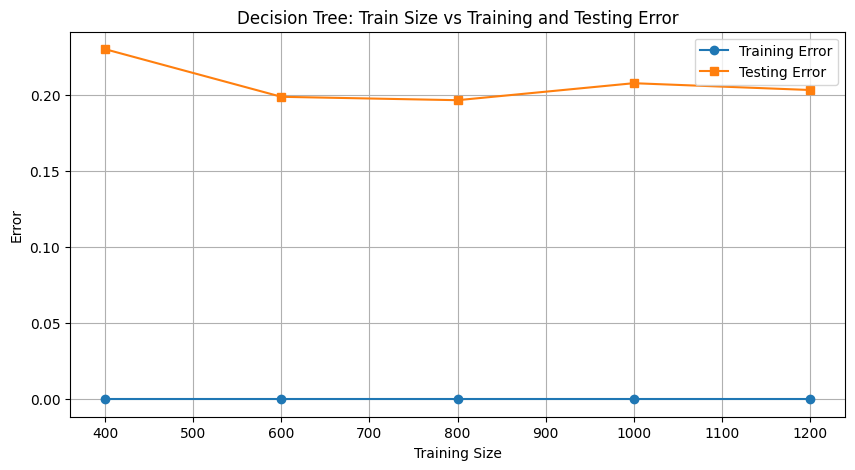

In [19]:

# --- Train size vs error ---
train_sizes = [400, 600, 800, 1000, 1200]
dt_size_results = []

for size in train_sizes:
    X_train_subset = X_train_scaled[:size]
    y_train_subset = y_train[:size]

    dt_model = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_SEED)
    dt_model.fit(X_train_subset, y_train_subset.ravel())

    y_train_pred = dt_model.predict(X_train_subset)
    train_error = 1 - accuracy_score(y_train_subset, y_train_pred)

    y_test_pred = dt_model.predict(X_test_scaled)
    test_error = 1 - accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    dt_size_results.append({'train_size': size, 'train_error': train_error, 'test_error': test_error, 'test_f1': test_f1})
    print(f"Train Size: {size} | Train Error: {train_error:.4f} | Test Error: {test_error:.4f} | Test F1: {test_f1:.4f}")

dt_size_results_arr = np.array([(r['train_size'], r['train_error'], r['test_error']) for r in dt_size_results])

plt.figure(figsize=(10, 5))
plt.title("Decision Tree: Train Size vs Training and Testing Error")
plt.xlabel("Training Size")
plt.ylabel("Error")
plt.plot(dt_size_results_arr[:, 0], dt_size_results_arr[:, 1], marker='o', linestyle='-', label="Training Error")
plt.plot(dt_size_results_arr[:, 0], dt_size_results_arr[:, 2], marker='s', linestyle='-', label="Testing Error")
plt.legend()
plt.grid(True)
plt.savefig("dt_train_size_vs_error.png")
plt.show()

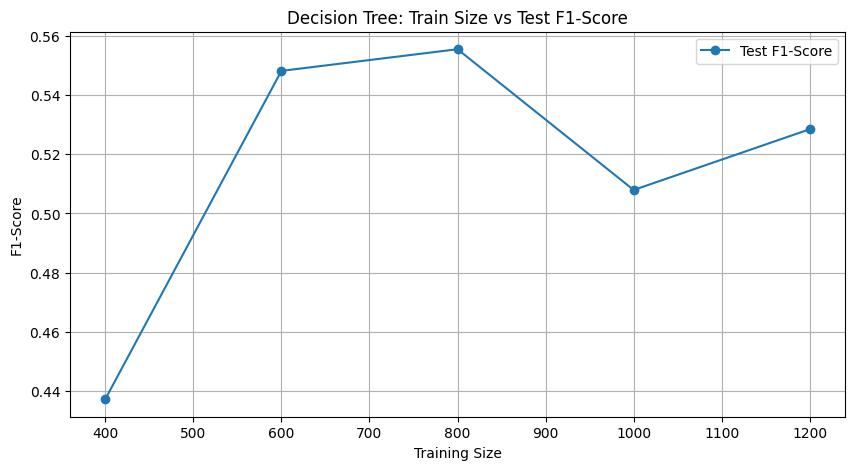

In [20]:
# --- Train size vs F1 ---
plt.figure(figsize=(10, 5))
plt.title("Decision Tree: Train Size vs Test F1-Score")
plt.xlabel("Training Size")
plt.ylabel("F1-Score")
plt.plot([r['train_size'] for r in dt_size_results], [r['test_f1'] for r in dt_size_results], marker='o', label="Test F1-Score")
plt.legend()
plt.grid(True)
plt.savefig("dt_train_size_vs_f1.png")
plt.show()

Since we have a working decision tree that we have tuned up, it is time to look into what it actually has to say about our features and dig into the explainability of the model 

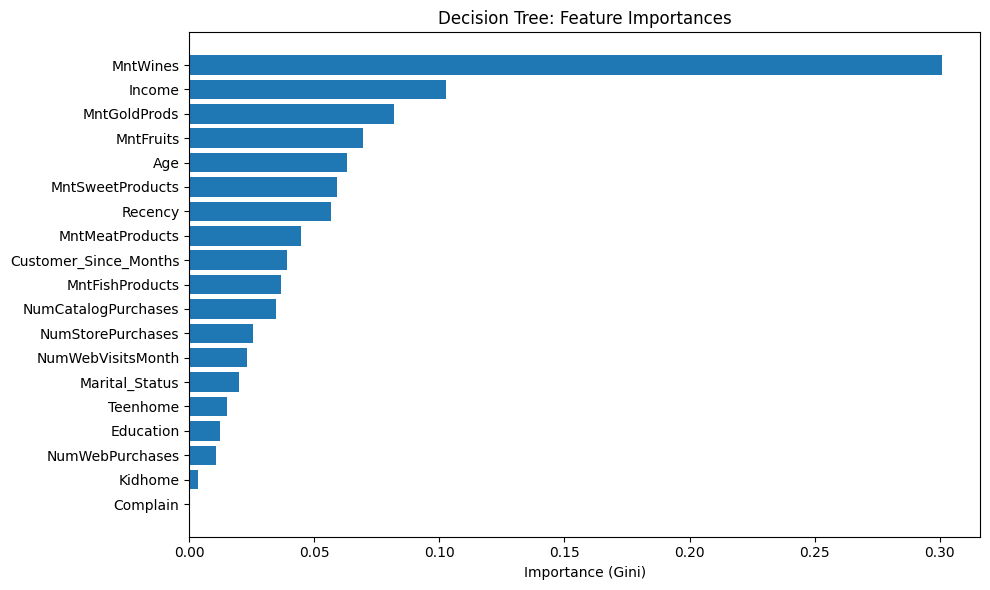


Top 10 features by importance:
  MntWines                       0.3010
  Income                         0.1028
  MntGoldProds                   0.0820
  MntFruits                      0.0694
  Age                            0.0631
  MntSweetProducts               0.0591
  Recency                        0.0568
  MntMeatProducts                0.0447
  Customer_Since_Months          0.0391
  MntFishProducts                0.0365


In [21]:
# --- Feature Importance ---
importances = dt_model.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

plt.figure(figsize=(10, 6))
plt.title("Decision Tree: Feature Importances")
plt.barh(range(len(sorted_features)), sorted_importances[::-1])
plt.yticks(range(len(sorted_features)), sorted_features[::-1])
plt.xlabel("Importance (Gini)")
plt.tight_layout()
plt.savefig("dt_feature_importance.png")
plt.show()

print("\nTop 10 features by importance:")
for feat, imp in zip(sorted_features[:10], sorted_importances[:10]):
    print(f"  {feat:<30} {imp:.4f}")

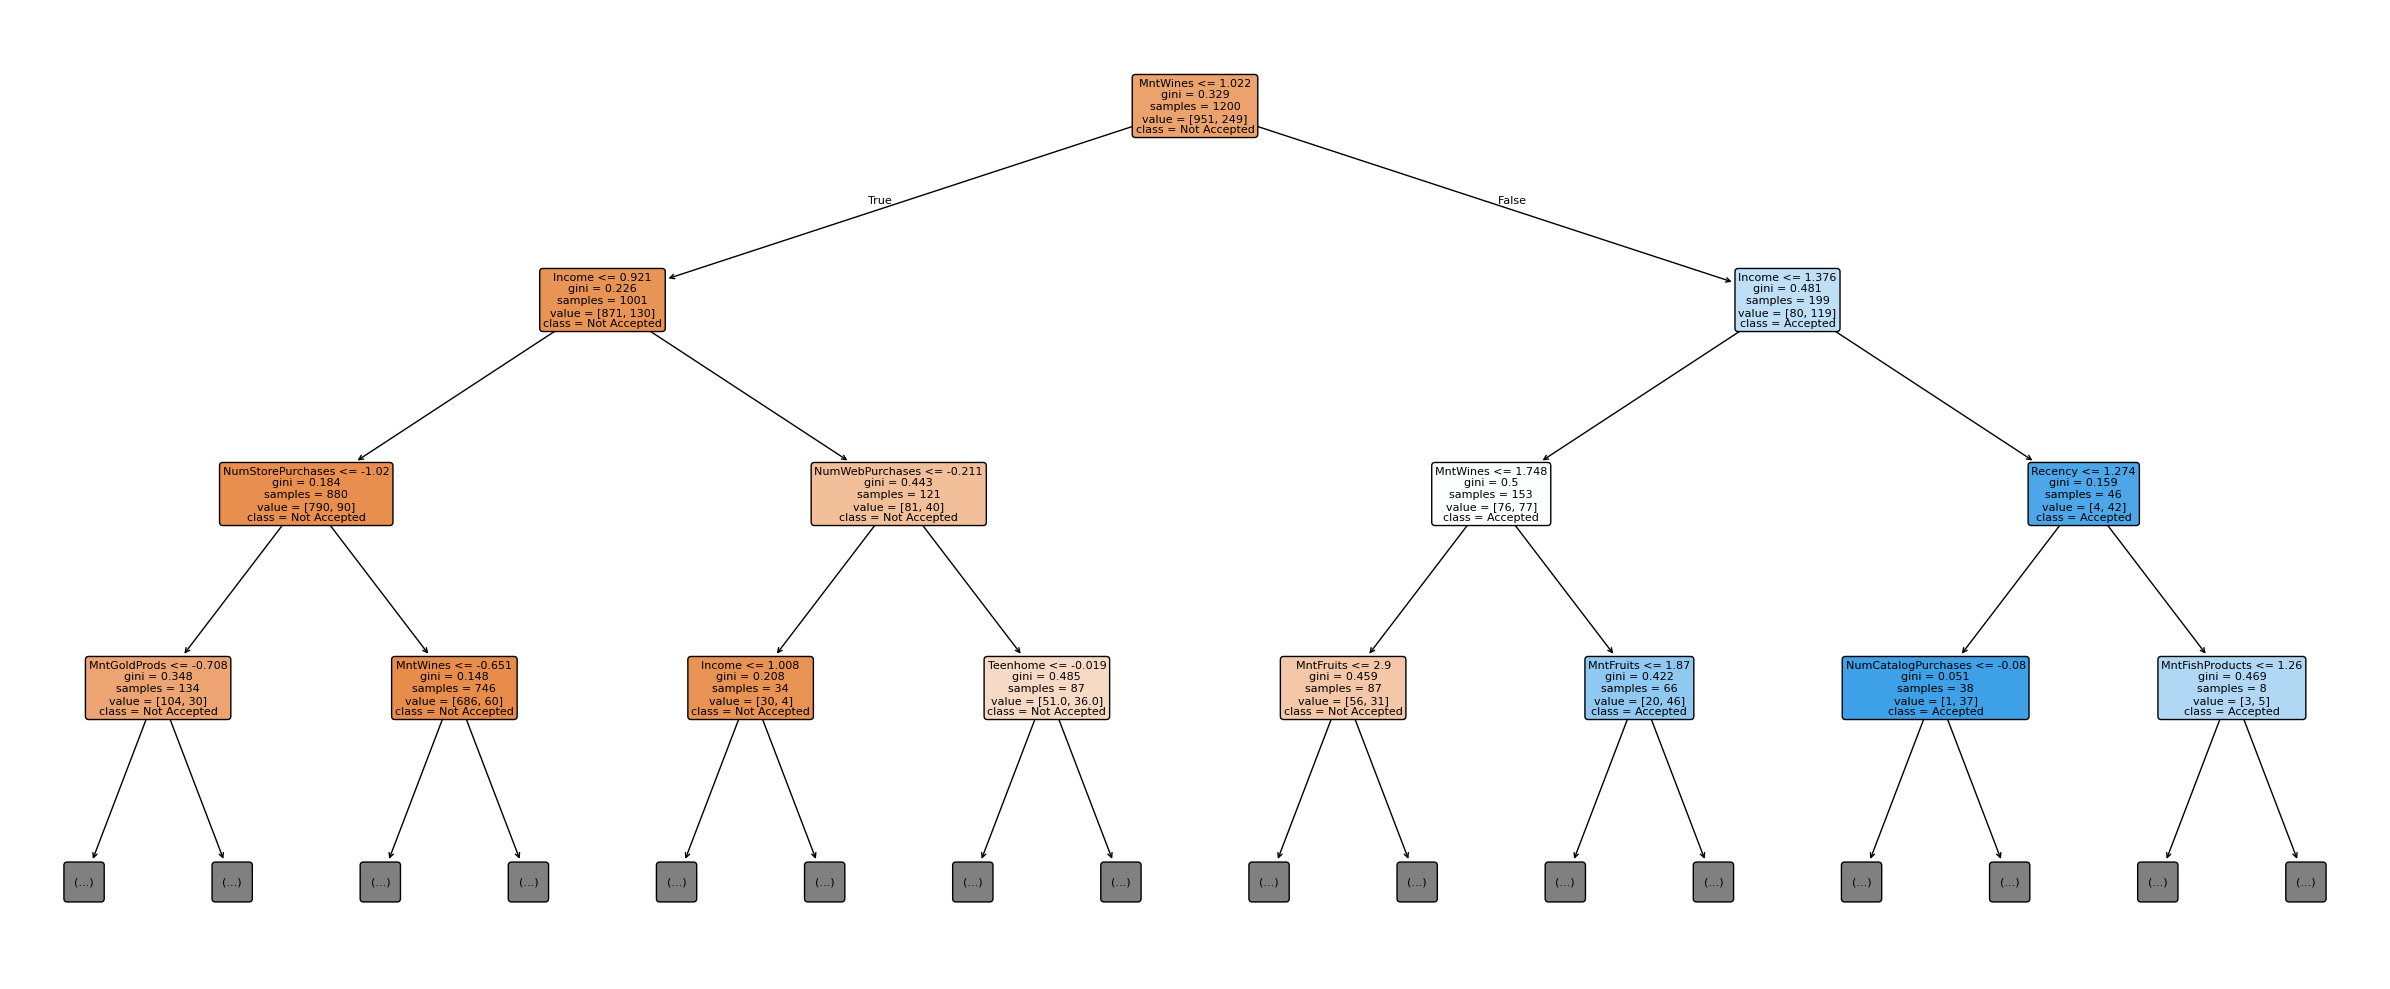

In [ ]:
# --- Tree Visualization (first 2 levels for readability) ---
from sklearn.tree import plot_tree

plt.figure(figsize=(24, 10))
plt.title(f"Decision Tree Structure (max_depth={best_depth}, showing first 3 levels)")
plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=['Not Accepted', 'Accepted'],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=2
)
plt.tight_layout()
plt.savefig("dt_tree_visualization.png", dpi=150)
plt.show()

In [23]:
# --- Level-by-Level Analysis ---
from sklearn.tree import _tree
from collections import defaultdict, deque

tree_ = dt_model.tree_
node_feature = [
    feature_names[i] if i != _tree.TREE_UNDEFINED else None
    for i in tree_.feature
]

# BFS to group nodes by depth
levels = defaultdict(list)
queue = deque([(0, 0)])
while queue:
    node_id, depth = queue.popleft()
    levels[depth].append(node_id)
    left = tree_.children_left[node_id]
    right = tree_.children_right[node_id]
    if left != _tree.TREE_LEAF:
        queue.append((left, depth + 1))
        queue.append((right, depth + 1))

print(f"Tree depth: {dt_model.get_depth()} | Total nodes: {tree_.node_count}\n")
print(f"{'Level':<7} {'Nodes':<7} {'Splits':<8} {'Leaves':<8} {'Samples covered':<18} {'Features used at this level'}")
print("-" * 90)

for depth in sorted(levels.keys()):
    nodes = levels[depth]
    split_nodes = [n for n in nodes if tree_.children_left[n] != _tree.TREE_LEAF]
    leaf_nodes  = [n for n in nodes if tree_.children_left[n] == _tree.TREE_LEAF]
    total_samples = sum(tree_.n_node_samples[n] for n in nodes)

    feat_counts = defaultdict(int)
    for n in split_nodes:
        feat_counts[node_feature[n]] += 1
    feat_str = ", ".join(f"{f}×{c}" if c > 1 else f for f, c in
                         sorted(feat_counts.items(), key=lambda x: -x[1]))

    print(f"{depth:<7} {len(nodes):<7} {len(split_nodes):<8} {len(leaf_nodes):<8} {total_samples:<18} {feat_str}")

print("\n--- Split details by level ---")
for depth in sorted(levels.keys()):
    split_nodes = [n for n in levels[depth] if tree_.children_left[n] != _tree.TREE_LEAF]
    if not split_nodes:
        continue
    print(f"\nLevel {depth}:")
    for n in split_nodes:
        feat   = node_feature[n]
        thresh = tree_.threshold[n]
        samples = tree_.n_node_samples[n]
        values = tree_.value[n][0]
        majority = "Accepted" if values[1] > values[0] else "Not Accepted"
        print(f"  Node {n:>4}: {feat} <= {thresh:.3f}  "
              f"| samples={samples}  | class dist=[{int(values[0])}, {int(values[1])}]  | majority={majority}")

Tree depth: 19 | Total nodes: 287

Level   Nodes   Splits   Leaves   Samples covered    Features used at this level
------------------------------------------------------------------------------------------
0       1       1        0        1200               MntWines
1       2       2        0        1200               Income×2
2       4       4        0        1200               NumStorePurchases, NumWebPurchases, MntWines, Recency
3       8       8        0        1200               MntFruits×2, MntGoldProds, MntWines, Income, Teenhome, NumCatalogPurchases, MntFishProducts
4       16      11       5        1200               MntSweetProducts×3, NumWebVisitsMonth×2, MntGoldProds×2, MntFruits, Age, Education, MntFishProducts
5       22      15       7        1149               MntGoldProds×4, Age×2, Recency×2, MntFishProducts, MntWines, MntMeatProducts, MntSweetProducts, MntFruits, Customer_Since_Months, NumCatalogPurchases
6       30      18       12       1067               Income×3

Now that we have done our basic decision tree model, lets look into another highly explainable type of model the Generalized additive model.

In [24]:
# ============================================================
# GAM (Generalized Additive Model)
# ============================================================

from pygam import LogisticGAM

X_train, y_train, X_val, y_val, X_test, y_test = split_data(marketing_df, method='train_val_test')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# --- Hyperparameter tuning: n_splines and lam via pygam gridsearch ---
# pygam doesn't implement the sklearn estimator interface, so we use its
# built-in .gridsearch() to tune lam, and loop over n_splines ourselves.
n_splines_options = [ 18, 20, 22, 24]
lam_values = np.logspace(-1, 1, 3)  # [0.1, 1.0, 10.0]

gam_results = []
for n in n_splines_options:
    candidate = LogisticGAM(n_splines=n)

    start_time = time.time()
    candidate.gridsearch(X_train_scaled, y_train.ravel(), lam=lam_values)
    elapsed = time.time() - start_time

    y_val_pred = candidate.predict(X_val_scaled)
    val_f1 = f1_score(y_val, y_val_pred)

    # .lam is a nested list [[val], [val], ...] after gridsearch — take the first term
    best_lam = candidate.lam[0][0]
    gam_results.append({'n_splines': n, 'lam': best_lam, 'val_f1': val_f1, 'training_time': elapsed})

print("{:<12} {:<10} {:<10} {:<15}".format("n_splines", "lam", "F1-Score", "Training Time (s)"))
for r in gam_results:
    print("{:<12} {:<10} {:<10.4f} {:<15.4f}".format(r['n_splines'], r['lam'], r['val_f1'], r['training_time']))

best_gam = max(gam_results, key=lambda x: x['val_f1'])
print(f"\nBest Config: n_splines={best_gam['n_splines']}, lam={best_gam['lam']}, Val F1: {best_gam['val_f1']:.4f}")

Train: 1344, Val: 448, Test: 448


  0% (0 of 3) |                          | Elapsed Time: 0:00:00 ETA:  --:--:--
 33% (1 of 3) |########                  | Elapsed Time: 0:00:03 ETA:   0:00:06
 66% (2 of 3) |#################         | Elapsed Time: 0:00:10 ETA:   0:00:05
100% (3 of 3) |##########################| Elapsed Time: 0:00:14 Time:  0:00:14
  0% (0 of 3) |                          | Elapsed Time: 0:00:00 ETA:  --:--:--
 33% (1 of 3) |########                  | Elapsed Time: 0:00:06 ETA:   0:00:13
 66% (2 of 3) |#################         | Elapsed Time: 0:00:11 ETA:   0:00:05
100% (3 of 3) |##########################| Elapsed Time: 0:00:24 Time:  0:00:24
  0% (0 of 3) |                          | Elapsed Time: 0:00:00 ETA:  --:--:--
 33% (1 of 3) |########                  | Elapsed Time: 0:00:04 ETA:   0:00:08
 66% (2 of 3) |#################         | Elapsed Time: 0:00:07 ETA:   0:00:03
100% (3 of 3) |##########################| Elapsed Time: 0:00:10 Time:  0:00:10
  0% (0 of 3) |                         

n_splines    lam        F1-Score   Training Time (s)
18           10.0       0.5490     14.1820        
20           10.0       0.5641     25.0288        
22           10.0       0.5605     11.4355        
24           10.0       0.5478     13.7065        

Best Config: n_splines=20, lam=10.0, Val F1: 0.5641


In [25]:
# --- Evaluate best GAM on test set ---
gam_model = LogisticGAM(n_splines=best_gam['n_splines'], lam=best_gam['lam'])

start_time = time.time()
gam_model.fit(X_train_scaled, y_train.ravel())
end_time = time.time()
gam_training_time = end_time - start_time

y_test_pred = gam_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)

print(f"\nGAM (n_splines={best_gam['n_splines']}, lam={best_gam['lam']}) Test Results:")
print(f"Accuracy: {accuracy:.2f}")
print(f"F1-Score: {f1:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"Training Time: {gam_training_time:.4f} seconds")


GAM (n_splines=20, lam=10.0) Test Results:
Accuracy: 0.83
F1-Score: 0.48
Precision: 0.65
Recall: 0.38
Training Time: 3.9648 seconds


Train Size: 350 | Train Error: 0.1229 | Test Error: 0.1853 | Test F1: 0.4430
Train Size: 400 | Train Error: 0.1100 | Test Error: 0.1719 | Test F1: 0.5157
Train Size: 450 | Train Error: 0.1156 | Test Error: 0.1741 | Test F1: 0.4800
Train Size: 500 | Train Error: 0.1220 | Test Error: 0.1629 | Test F1: 0.5290
Train Size: 550 | Train Error: 0.1255 | Test Error: 0.1741 | Test F1: 0.4868
Train Size: 600 | Train Error: 0.1267 | Test Error: 0.1696 | Test F1: 0.4933


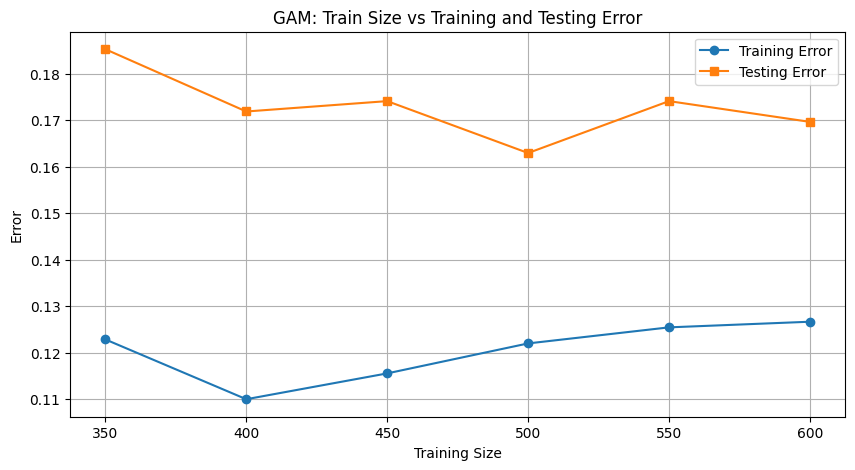

In [26]:
# --- Train size vs error ---
train_sizes = [ 350, 400, 450, 500, 550, 600]
gam_size_results = []

for size in train_sizes:
    X_train_subset = X_train_scaled[:size]
    y_train_subset = y_train[:size]

    gam_model = LogisticGAM(n_splines=best_gam['n_splines'], lam=best_gam['lam'])
    gam_model.fit(X_train_subset, y_train_subset.ravel())

    y_train_pred = gam_model.predict(X_train_subset)
    train_error = 1 - accuracy_score(y_train_subset, y_train_pred)

    y_test_pred = gam_model.predict(X_test_scaled)
    test_error = 1 - accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    gam_size_results.append({'train_size': size, 'train_error': train_error, 'test_error': test_error, 'test_f1': test_f1})
    print(f"Train Size: {size} | Train Error: {train_error:.4f} | Test Error: {test_error:.4f} | Test F1: {test_f1:.4f}")

gam_size_results_arr = np.array([(r['train_size'], r['train_error'], r['test_error']) for r in gam_size_results])

plt.figure(figsize=(10, 5))
plt.title("GAM: Train Size vs Training and Testing Error")
plt.xlabel("Training Size")
plt.ylabel("Error")
plt.plot(gam_size_results_arr[:, 0], gam_size_results_arr[:, 1], marker='o', linestyle='-', label="Training Error")
plt.plot(gam_size_results_arr[:, 0], gam_size_results_arr[:, 2], marker='s', linestyle='-', label="Testing Error")
plt.legend()
plt.grid(True)
plt.savefig("gam_train_size_vs_error.png")
plt.show()

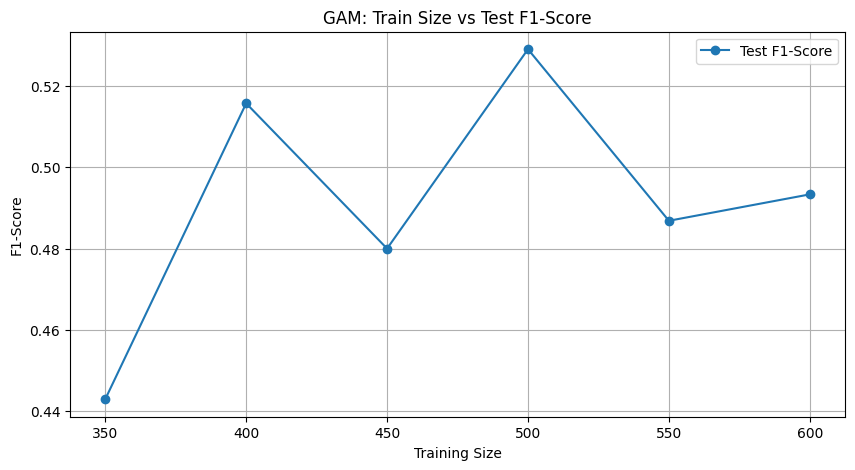

In [27]:
# --- Train size vs F1 ---
plt.figure(figsize=(10, 5))
plt.title("GAM: Train Size vs Test F1-Score")
plt.xlabel("Training Size")
plt.ylabel("F1-Score")
plt.plot([r['train_size'] for r in gam_size_results], [r['test_f1'] for r in gam_size_results], marker='o', label="Test F1-Score")
plt.legend()
plt.grid(True)
plt.savefig("gam_train_size_vs_f1.png")
plt.show()

Once again, we now have a fairly optimized GAM for the dataset, so lets do some analysis of how the various features impact the model.

In [ ]:
# --- Per-feature shape functions ---
# A GAM decomposes predictions as f(X) = β₀ + f₁(x₁) + f₂(x₂) + ... + fₙ(xₙ).
# Each shape function shows exactly how that feature shifts the log-odds of acceptance.

n_features = len(feature_names)
n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 5))
axes = axes.flatten()

for i, feat in enumerate(feature_names):
    ax = axes[i]
    XX = gam_model.generate_X_grid(term=i)
    pdep, confi = gam_model.partial_dependence(term=i, X=XX, width=0.95)

    # Shape function line
    ax.plot(XX[:, i], pdep, color='steelblue', linewidth=2, label='Partial effect')

    # 95% confidence band
    ax.fill_between(XX[:, i], confi[:, 0], confi[:, 1],
                    alpha=0.25, color='steelblue', label='95% CI')

    # Zero reference line
    ax.axhline(0, color='#333333', linestyle='--', linewidth=1.2, label='No effect')

    # Rug plot — show where training data actually falls
    ax.plot(X_train_scaled[:, i], np.full(X_train_scaled.shape[0], confi[:, 0].min()),
            '|', color='steelblue', alpha=0.15, markersize=6)

    # Titles and labels
    ax.set_title(feat, fontsize=12, fontweight='bold', pad=8)

    # Only label y-axis on leftmost column
    if i % n_cols == 0:
        ax.set_ylabel("Partial effect (log-odds)", fontsize=10)
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])

    # Only label x-axis on bottom row
    if i >= n_features - n_cols:
        ax.set_xlabel("Value (standardized)", fontsize=10)

    ax.grid(True, alpha=0.2, linestyle=':')
    ax.legend(fontsize=8, loc='best')

for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("GAM: Per-Feature Shape Functions\n(effect on log-odds of campaign acceptance)",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(pad=2.0)
plt.savefig("gam_shape_functions.png", dpi=150, bbox_inches='tight')
plt.show()

# Part 2: Accepting Optimizations to the Model types that improve performance and lower explainability

We are now going to look into improvements to both Decision Trees and GAM's that improve model performance but make big steps away from Explainability as part of the process. This is an extraordinarily common tradeoff and is most of the time well worth the exchange. Not every application needs perfect insight into which features are most important or which ones are being used to make decisions at each step of the process. 

In [34]:
# ============================================================
# XGBoost (Gradient Boosted Decision Tree)
# ============================================================

from xgboost import XGBClassifier

X_train, y_train, X_val, y_val, X_test, y_test = split_data(marketing_df, method='train_val_test')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# --- Hyperparameter tuning via GridSearchCV ---
param_grid = {
    'n_estimators': [ 200, 300, 400],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.1, 0.125, 0.15],
}

grid_search = GridSearchCV(
    XGBClassifier( eval_metric='logloss', random_state=RANDOM_SEED),
    param_grid,
    scoring='f1',
    cv=5,
    n_jobs=1
)

start_time = time.time()
grid_search.fit(X_train_scaled, y_train.ravel())
end_time = time.time()

best_xgb = grid_search.best_params_
best_xgb_cv_f1 = grid_search.best_score_
print(f"Best Config: {best_xgb}, CV F1: {best_xgb_cv_f1:.4f}")
print(f"Grid search time: {end_time - start_time:.4f}s")

print("\n{:<15} {:<12} {:<15} {:<10}".format("n_estimators", "max_depth", "learning_rate", "CV F1"))
for mean, params in zip(grid_search.cv_results_['mean_test_score'],
                        grid_search.cv_results_['params']):
    print("{:<15} {:<12} {:<15} {:<10.4f}".format(
        params['n_estimators'], params['max_depth'], params['learning_rate'], mean))

Train: 1344, Val: 448, Test: 448
Best Config: {'learning_rate': 0.125, 'max_depth': 5, 'n_estimators': 300}, CV F1: 0.5989
Grid search time: 39.5631s

n_estimators    max_depth    learning_rate   CV F1     
200             3            0.1             0.5530    
300             3            0.1             0.5813    
400             3            0.1             0.5845    
200             5            0.1             0.5845    
300             5            0.1             0.5857    
400             5            0.1             0.5735    
200             7            0.1             0.5812    
300             7            0.1             0.5754    
400             7            0.1             0.5848    
200             3            0.125           0.5620    
300             3            0.125           0.5800    
400             3            0.125           0.5844    
200             5            0.125           0.5914    
300             5            0.125           0.5989    
400      

In [36]:

# --- Evaluate best XGBoost on test set ---
xgb_model = XGBClassifier(
    n_estimators=best_xgb['n_estimators'],
    max_depth=best_xgb['max_depth'],
    learning_rate=best_xgb['learning_rate'],
    eval_metric='logloss',
    random_state=RANDOM_SEED
)

start_time = time.time()
xgb_model.fit(X_train_scaled, y_train.ravel())
end_time = time.time()
xgb_training_time = end_time - start_time

y_test_pred = xgb_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)

print(f"\nXGBoost Test Results:")
print(f"Accuracy: {accuracy:.2f}")
print(f"F1-Score: {f1:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"Training Time: {xgb_training_time:.4f} seconds")


XGBoost Test Results:
Accuracy: 0.85
F1-Score: 0.59
Precision: 0.69
Recall: 0.52
Training Time: 0.3225 seconds


Train Size: 400 | Train Error: 0.0000 | Test Error: 0.1719 | Test F1: 0.4832
Train Size: 600 | Train Error: 0.0000 | Test Error: 0.1585 | Test F1: 0.5298
Train Size: 800 | Train Error: 0.0000 | Test Error: 0.1473 | Test F1: 0.5769
Train Size: 1000 | Train Error: 0.0000 | Test Error: 0.1540 | Test F1: 0.5605
Train Size: 1200 | Train Error: 0.0000 | Test Error: 0.1585 | Test F1: 0.5590
Train Size: 1344 | Train Error: 0.0000 | Test Error: 0.1496 | Test F1: 0.5890


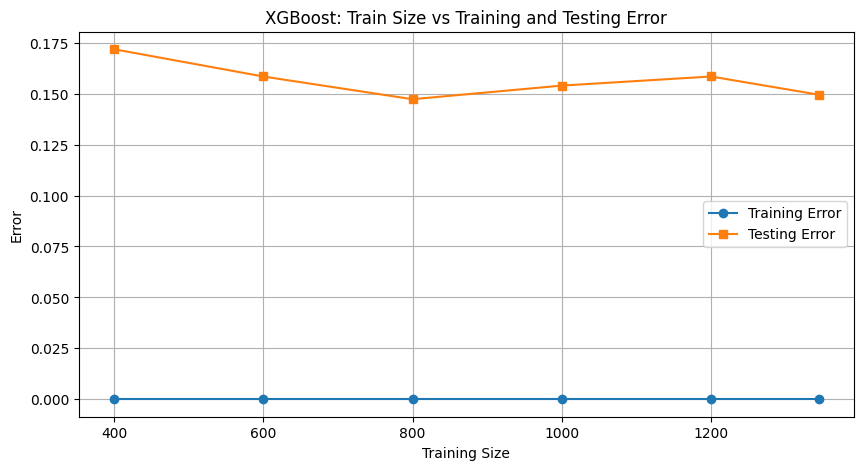

In [40]:

# --- Train size vs error ---
train_sizes = [400, 600, 800, 1000, 1200, 1344]
xgb_size_results = []

for size in train_sizes:
    X_train_subset = X_train_scaled[:size]
    y_train_subset = y_train[:size]

    xgb_model = XGBClassifier(
        n_estimators=best_xgb['n_estimators'],
        max_depth=best_xgb['max_depth'],
        learning_rate=best_xgb['learning_rate'],
        eval_metric='logloss',
        random_state=RANDOM_SEED
    )
    xgb_model.fit(X_train_subset, y_train_subset.ravel())

    y_train_pred = xgb_model.predict(X_train_subset)
    train_error = 1 - accuracy_score(y_train_subset, y_train_pred)

    y_test_pred = xgb_model.predict(X_test_scaled)
    test_error = 1 - accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    xgb_size_results.append({'train_size': size, 'train_error': train_error, 'test_error': test_error, 'test_f1': test_f1})
    print(f"Train Size: {size} | Train Error: {train_error:.4f} | Test Error: {test_error:.4f} | Test F1: {test_f1:.4f}")

xgb_size_results_arr = np.array([(r['train_size'], r['train_error'], r['test_error']) for r in xgb_size_results])

plt.figure(figsize=(10, 5))
plt.title("XGBoost: Train Size vs Training and Testing Error")
plt.xlabel("Training Size")
plt.ylabel("Error")
plt.plot(xgb_size_results_arr[:, 0], xgb_size_results_arr[:, 1], marker='o', linestyle='-', label="Training Error")
plt.plot(xgb_size_results_arr[:, 0], xgb_size_results_arr[:, 2], marker='s', linestyle='-', label="Testing Error")
plt.legend()
plt.grid(True)
plt.savefig("xgb_train_size_vs_error.png")
plt.show()

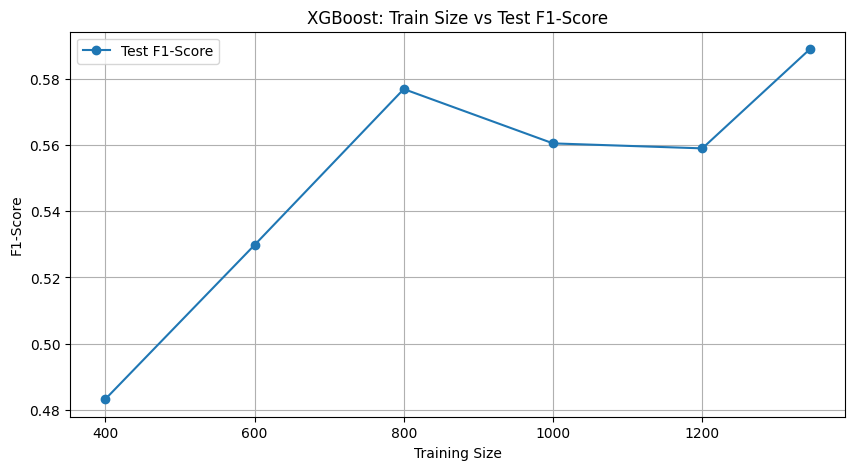

In [41]:

# --- Train size vs F1 ---
plt.figure(figsize=(10, 5))
plt.title("XGBoost: Train Size vs Test F1-Score")
plt.xlabel("Training Size")
plt.ylabel("F1-Score")
plt.plot([r['train_size'] for r in xgb_size_results], [r['test_f1'] for r in xgb_size_results], marker='o', label="Test F1-Score")
plt.legend()
plt.grid(True)
plt.savefig("xgb_train_size_vs_f1.png")
plt.show()